Load data and model

In [1]:
import pandas as pd
import pickle
import sys
sys.path.append("..")

df = pd.read_pickle("../data/features_v2.pkl")
df = df.drop(columns=["embedding"])

with open("../models/model_v3.pkl", "rb") as f:
    model = pickle.load(f)

Prepare the data

In [2]:
from python_editor.data_processing import split_by_developer, get_vectorized_features_and_label

train, test = split_by_developer(df, test_size=0.3, random_state=0)

In [3]:
from python_editor.feature_generation_v2 import TRANSFORMED_FEATURES, LOG_FEATURES, BINARY_FEATURES, generate_transformed_features

X_train, y_train = get_vectorized_features_and_label(train, TRANSFORMED_FEATURES)
X_test, y_test = get_vectorized_features_and_label(test, TRANSFORMED_FEATURES)

Get shap values and reverse log features

In [4]:
import shap
from python_editor.model_evaluation import get_shap_df
shap.initjs()

shap_values = get_shap_df(model, TRANSFORMED_FEATURES, X_train, X_train)

100%|===================| 2415/2419 [06:21<00:00]        

In [5]:
import numpy as np

for feat in LOG_FEATURES:
    mask = np.array(shap_values.feature_names) == feat
    shap_values.data[:, mask] = np.expm1(shap_values.data[:, mask])

Features are divided into three categories:

1- always have positive effect (e.g., has_docstring)

2- never have positive effect (e.g., long_line)

3- have positive effect in a certain range (e.g., characters)

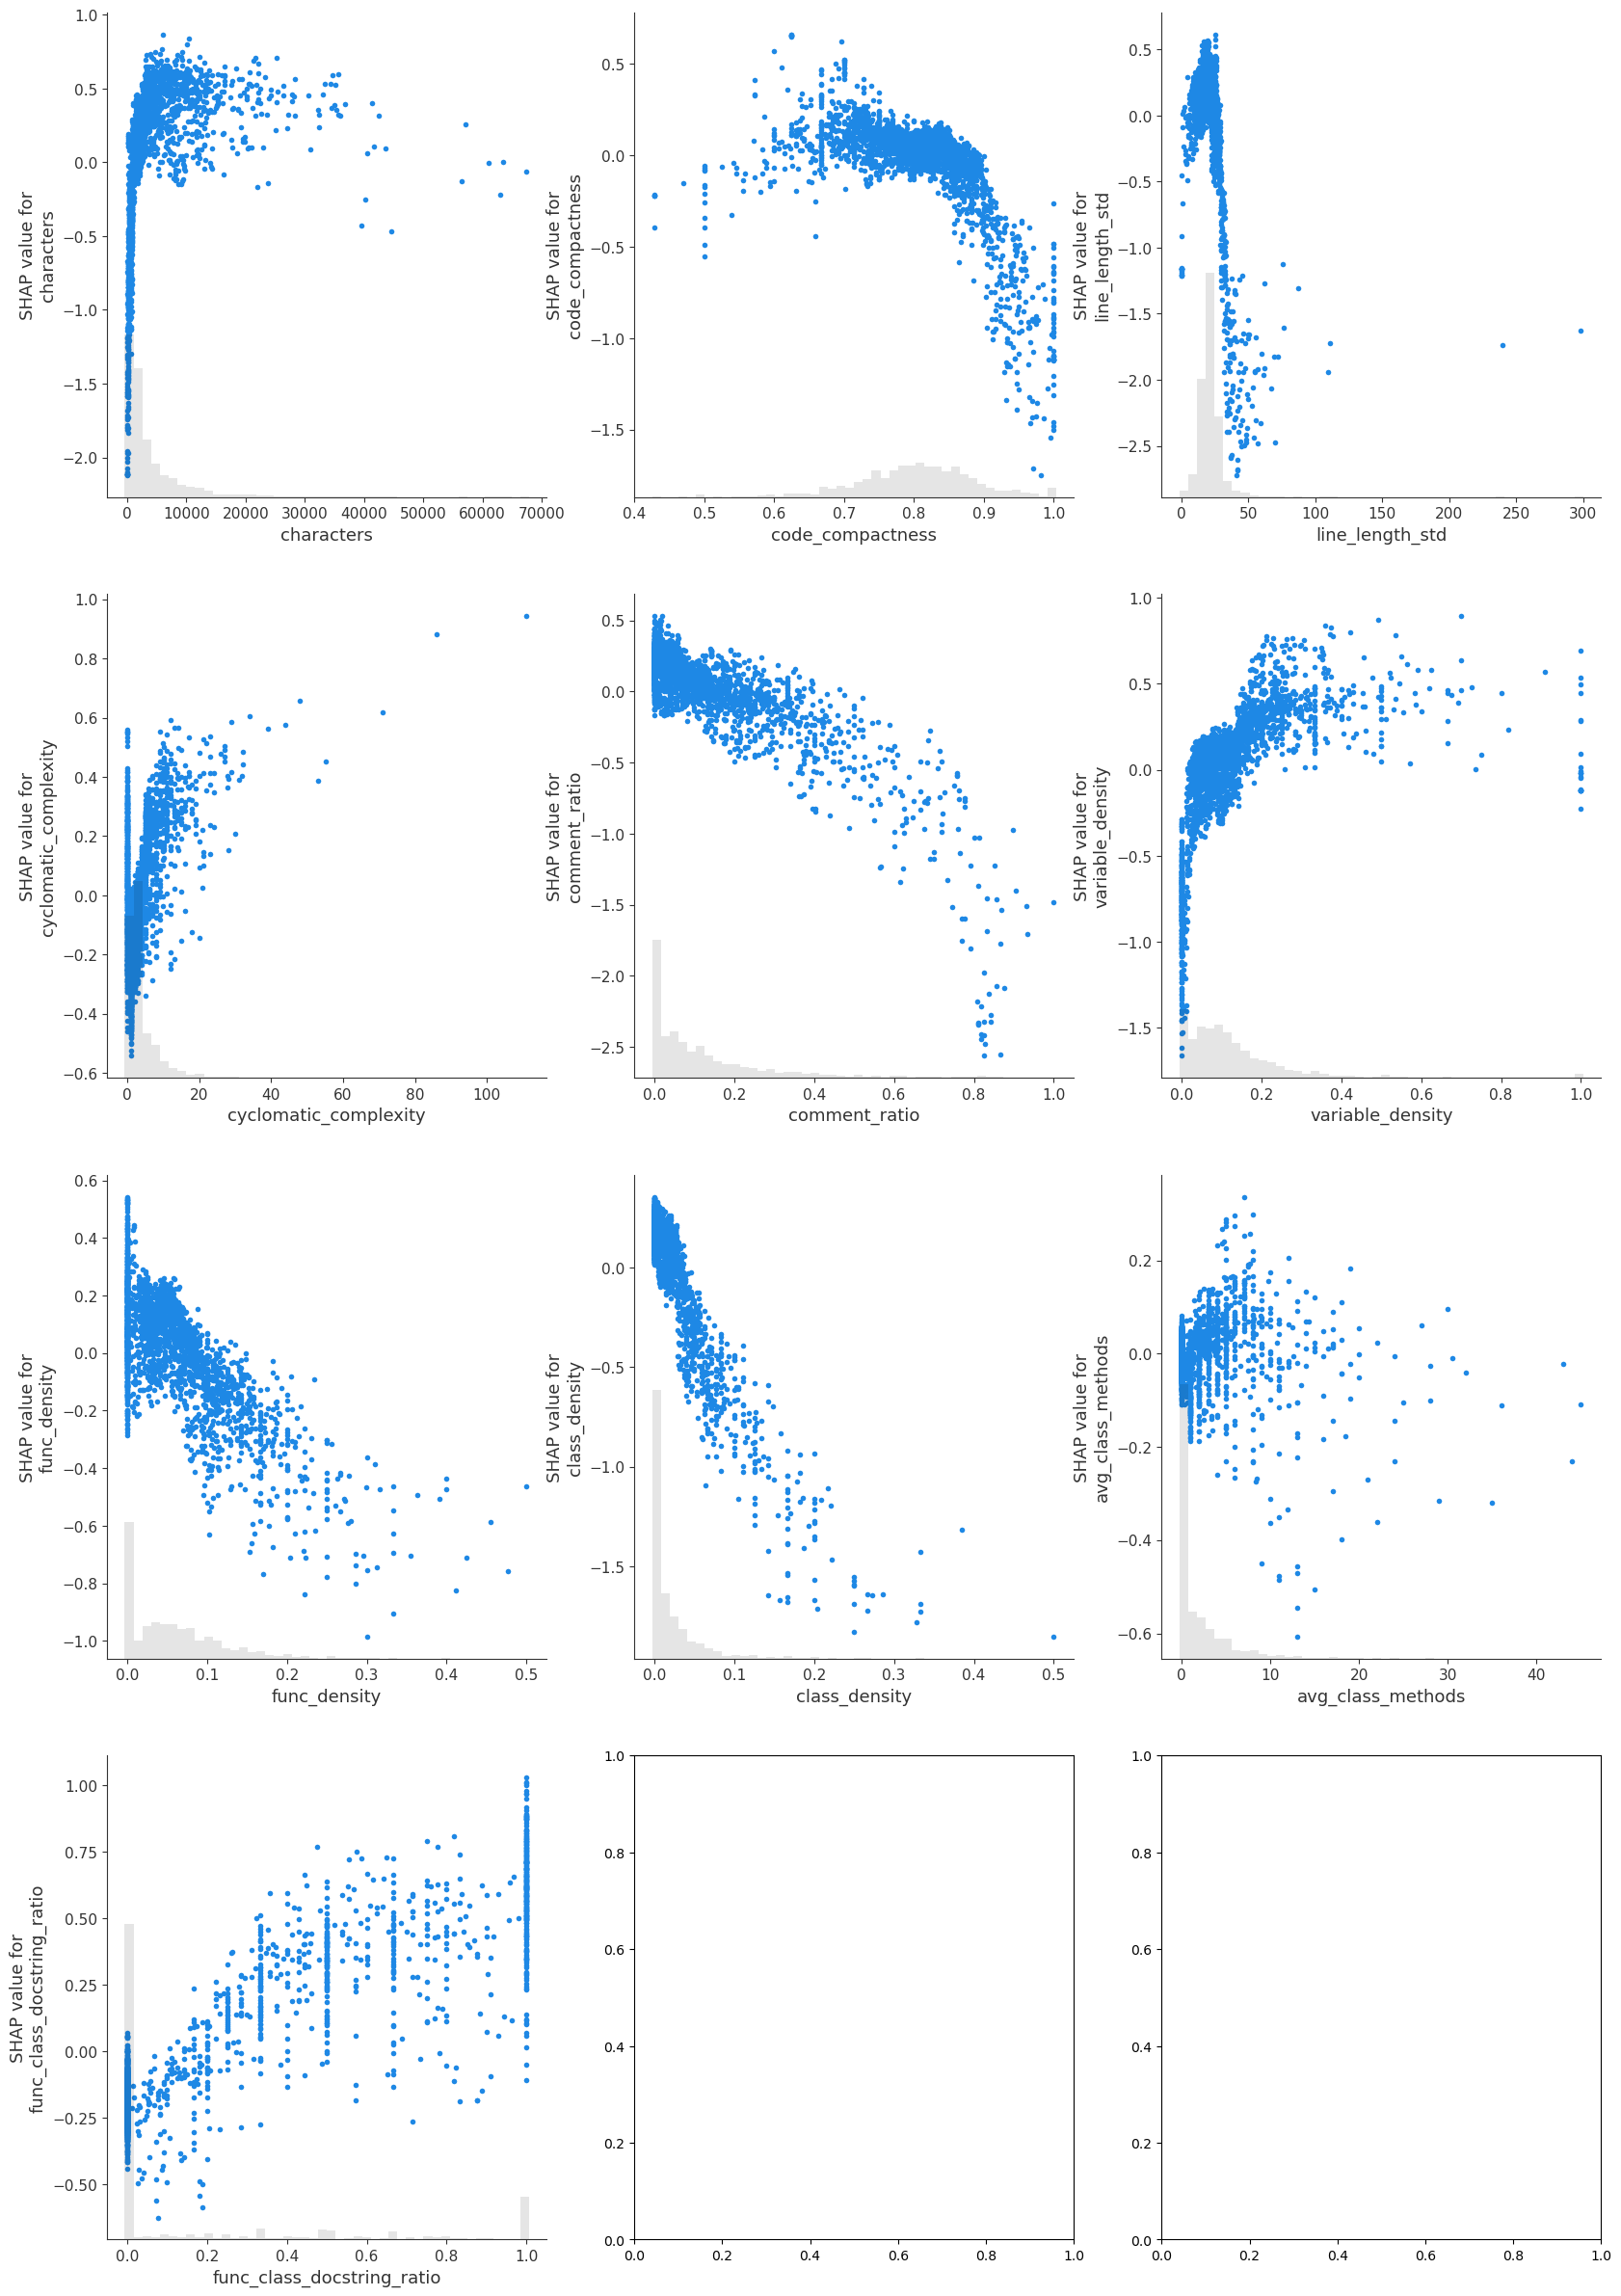

In [6]:
import matplotlib.pyplot as plt
import math

NUMERICAL_FEATURES = [feat for feat in TRANSFORMED_FEATURES if feat not in BINARY_FEATURES]

# Create subplots
fig, axes = plt.subplots(math.ceil(len(NUMERICAL_FEATURES) / 3), 3, figsize=(20, 30))

for i, feat in enumerate(NUMERICAL_FEATURES):
    axis = axes[i // 3, i % 3]
    shap.plots.scatter(shap_values[:, feat], ax=axis, show=False)

plt.show()

Examining the force plot helps us identify the ranges of positive effect for each feature

In [7]:
shap.plots.force(shap_values[:, NUMERICAL_FEATURES])

In [8]:
one_directional_effects = {
    "long_line":                  "never",
    "bad_name":                   "never",
    "too_many_args":              "never",
    "unused_imports":             "never",
    "has_docstring":              "always",
    "func_class_docstring_ratio": "always"
}

range_features = TRANSFORMED_FEATURES.copy()
for feat in one_directional_effects.keys():
    range_features.remove(feat)

Determining the widest positive effect by looking at the plots is time consuming and will be inefficient for automatic retraining. We implement a function get_widest_pos_range which does this. The parameter window is used to smooth shap values to get ranges where shap values are consistently positive

In [9]:
from python_editor.generate_recommendations import get_widest_pos_range, get_recommendations, construct_recommendations

range_effects = get_widest_pos_range(shap_values, range_features, window=5)
range_effects

{'characters': (np.float64(1847.9999999999998), np.float64(40245.99999999997)),
 'code_compactness': (np.float64(0.6617647058823529),
  np.float64(0.7307692307692307)),
 'line_length_std': (np.float64(14.324367350776784),
  np.float64(22.275880313693555)),
 'cyclomatic_complexity': (np.float64(12.0), np.float64(110.99999999999996)),
 'comment_ratio': (np.float64(0.023255813953488372),
  np.float64(0.0958904109589041)),
 'variable_density': (np.float64(0.14285714285714285), np.float64(1.0)),
 'func_density': (np.float64(0.047619047619047616),
  np.float64(0.05555555555555555)),
 'class_density': (np.float64(0.0), np.float64(0.0136986301369863)),
 'avg_class_methods': (np.float64(6.0), np.float64(8.0))}

The function get_recommendations gets the features with the most negative shap values in the input and determines how these features should be modified to increase the score depending on FEATURES_POS_EFFECTS.

If the feature with the most negative shap value is for example avg_class_methods but at the same time the input has no classes it will be nonsense to recommend modifing class methods but rather to include classes in the code. We add DEPENDENCIES to overcome this obstacle.

In [10]:
FEATURES_POS_EFFECTS =  range_effects | one_directional_effects

DEPENDENCIES = {
    "avg_class_methods": "class_density",
    "func_class_docstring_ratio": ["func_density", "class_density"]
}

row = pd.Series({"text": "import pandas as pd\nif __name__ == '__main__':\n    print('hello')\n"})

features, score, recommendations = get_recommendations(
                                                        row, generate_transformed_features, model, X_train,
                                                        FEATURES_POS_EFFECTS, DEPENDENCIES, LOG_FEATURES
                                                        )
features, score, recommendations

({'characters': np.float64(4.204692619390966),
  'code_compactness': 1.0,
  'line_length_std': np.float64(1.5171090226473645),
  'cyclomatic_complexity': np.float64(0.0),
  'long_line': 0,
  'bad_name': 0,
  'comment_ratio': 0.0,
  'has_docstring': 0,
  'variable_density': 0.0,
  'func_density': 0.0,
  'too_many_args': 0,
  'class_density': 0.0,
  'avg_class_methods': 0,
  'func_class_docstring_ratio': 0,
  'unused_imports': 1},
 2.6316529123446943,
 {'code_compactness': 'decrease',
  'cyclomatic_complexity': 'increase',
  'variable_density': 'increase'})

Finally we construct the recommendation message and print it

In [13]:
RECOMMENDATION_MSGS = {
    "characters": {
        "type": "range",
        "increase_msg": "The file appears very small. Consider adding meaningful structure or consolidating related files.",
        "decrease_msg": "The file is quite large. Consider splitting it into smaller, more focused modules.",
        "neutral_msg": "File size looks reasonable."
    },

    "code_compactness": {
        "type": "range",
        "increase_msg": "The code has excessive spacing. Tighten layout where it does not affect readability.",
        "decrease_msg": "The code appears overly dense. Add blank lines to improve readability.",
        "neutral_msg": "Code spacing looks balanced."
    },

    "line_length_std": {
        "type": "range",
        "increase_msg": "Line lengths are very uniform. Slight variation is fine if it improves readability.",
        "decrease_msg": "Line lengths are inconsistent. Keep them more uniform for better readability.",
        "neutral_msg": "Line length consistency looks good."
    },

    "cyclomatic_complexity": {
        "type": "range",
        "increase_msg": "The code may be overly trivial. Ensure logic is meaningful and not overly fragmented.",
        "decrease_msg": "The code is complex. Simplify logic, reduce branching, or break into smaller functions.",
        "neutral_msg": "Code complexity looks reasonable."
    },

    "comment_ratio": {
        "type": "range",
        "increase_msg": "Add comments where the intent or logic is not immediately clear.",
        "decrease_msg": "Reduce redundant comments and focus on explaining intent rather than obvious code.",
        "neutral_msg": "Comment usage looks balanced."
    },

    "variable_density": {
        "type": "range",
        "increase_msg": "Introduce well-named intermediate variables where they improve clarity.",
        "decrease_msg": "Too many variables may hurt readability. Simplify where possible.",
        "neutral_msg": "Variable usage looks balanced."
    },

    "func_density": {
        "type": "range",
        "increase_msg": "Refactor repeated or complex logic into functions.",
        "decrease_msg": "The code may be over-fragmented into too many small functions. Consolidate where appropriate.",
        "neutral_msg": "Function usage looks balanced."
    },

    "class_density": {
        "type": "range",
        "increase_msg": "Use classes where grouped state or behavior would improve structure.",
        "decrease_msg": "The code may use unnecessary classes. Prefer simpler structures where appropriate.",
        "neutral_msg": "Class usage looks balanced."
    },

    "avg_class_methods": {
        "type": "range",
        "increase_msg": "Classes may be too minimal. Consider grouping related behavior.",
        "decrease_msg": "Some classes have too many methods. Split responsibilities into smaller classes.",
        "neutral_msg": "Class responsibilities look balanced."
    },

    "long_line": {
        "type": "decrease",
        "decrease_msg": "Break long lines to improve readability and follow style conventions."
    },

    "bad_name": {
        "type": "decrease",
        "decrease_msg": "Use clearer and more descriptive names for variables, functions, or classes."
    },

    "too_many_args": {
        "type": "decrease",
        "decrease_msg": "Reduce the number of function/method parameters by grouping related inputs or refactoring."
    },

    "unused_imports": {
        "type": "decrease",
        "decrease_msg": "Remove unused imports."
    },

    "has_docstring": {
        "type": "increase",
        "increase_msg": "Add a module docstring describing the purpose of the file."
    },

    "func_class_docstring_ratio": {
        "type": "increase",
        "increase_msg": "Add docstrings to functions and classes to explain their purpose and usage."
    },
}

In [14]:
message = construct_recommendations(score, recommendations, RECOMMENDATION_MSGS)
print(message)

Estimated score: 2.63

Suggested improvements:

The code appears overly dense. Add blank lines to improve readability.

The code may be overly trivial. Ensure logic is meaningful and not overly fragmented.

Introduce well-named intermediate variables where they improve clarity.




We save FEATURES_POS_EFFECTS, DEPENDENCIES and RECOMMENDATION_MSGS. We do not hard code them to enable flexibilty in future models

In [16]:
import pickle

with open("../recommendation_data/model_v3/features_pos_effects.pkl", "wb") as f:
    pickle.dump(FEATURES_POS_EFFECTS, f)

with open("../recommendation_data/model_v3/dependencies.pkl", "wb") as f:
    pickle.dump(DEPENDENCIES, f)

with open("../recommendation_data/model_v3/recommendation_msgs.pkl", "wb") as f:
    pickle.dump(RECOMMENDATION_MSGS, f)